In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/dataset/mmash_for_interpolation_test.csv")

In [3]:
df = df[df['user_id'] == 4018081 ]

In [12]:
df.shape

(1087256, 11)

In [4]:
# Weighted Moving Average
def weighted_moving_average(series, window=5):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

df['hr_weighted_avg'] = df['heart_rate'].rolling(window=10, center=True).mean()


In [5]:
try:
    # For very large datasets like yours (51M rows), spline might be slow.
    # We limit the limit_direction to fill all gaps.
    df['hr_spline'] = df['heart_rate'].interpolate(method='cubic')
except Exception as e:
    print(f"Cubic spline error (likely memory or index): {e}")
    df['hr_spline'] = df['hr_linear'] # Fallback


In [6]:
df['hr_linear'] = df['heart_rate'].interpolate(method='linear')

In [8]:
df.head(-40)

,time,x,y,z,heart_rate,sleep_stage,steps,user_id,hr_weighted_avg,hr_spline
0,-24483.449456,0.121704,-0.440369,-0.890656,NaN,NaN,0.0,4018081,NaN,NaN
1,-24483.431540,0.120666,-0.436951,-0.888733,NaN,NaN,0.0,4018081,NaN,NaN
2,-24483.411333,0.116714,-0.439392,-0.885895,NaN,NaN,0.0,4018081,NaN,NaN
3,-24483.391450,0.118652,-0.438400,-0.885376,NaN,NaN,0.0,4018081,NaN,NaN
4,-24483.371426,0.118744,-0.436951,-0.889740,NaN,NaN,0.0,4018081,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
51819106,28827.665691,0.483185,0.329269,-0.709747,NaN,-1.0,0.0,844359,NaN,NaN
51819107,28827.666143,0.563980,0.383194,-0.679535,NaN,-1.0,0.0,844359,NaN,NaN
51819108,28827.666528,0.616867,0.432632,-0.669815,NaN,-1.0,0.0,844359,NaN,NaN
51819109,28827.666904,0.607163,0.441879,-0.673431,NaN,-1.0,0.0,844359,NaN,NaN


In [8]:
print(df.count())

time               1087256
x                  1087256
y                  1087256
z                  1087256
heart_rate          217261
sleep_stage         965961
steps              1087256
user_id            1087256
hr_weighted_avg     189901
hr_spline          1086556
hr_linear          1086696
dtype: int64


In [ ]:
df.info()

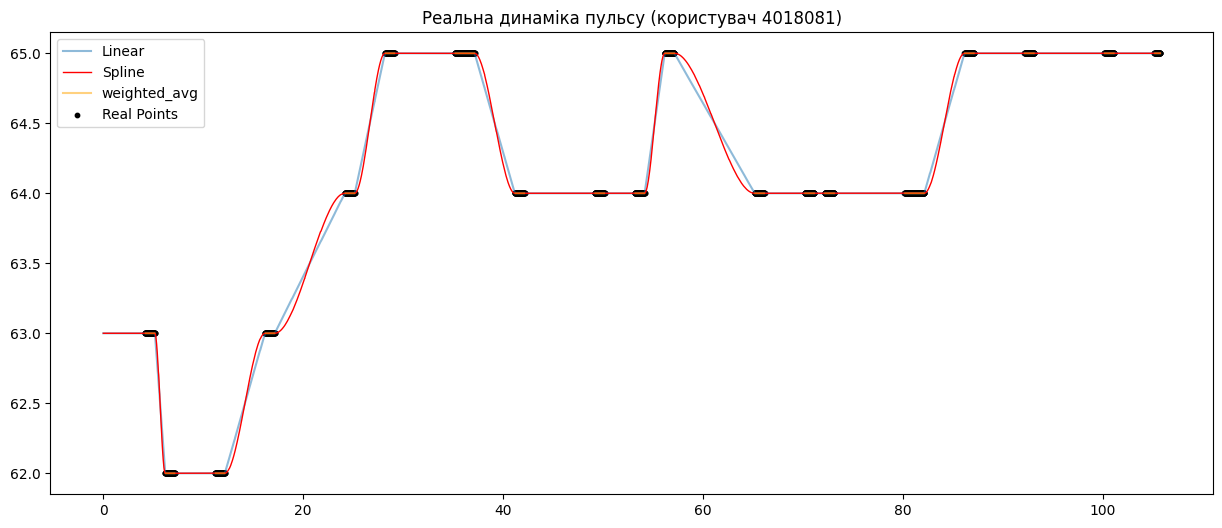

In [7]:
target_user = 4018081
user_data = df[df['user_id'] == target_user]

# 5000 рядків ~2.5 хвилини
sample_size = 7000
start_idx = len(user_data) // 2
user_sample = user_data.iloc[start_idx : start_idx + sample_size].copy()

# Обчислимо відносний час
user_sample['time_rel'] = user_sample['time'] - user_sample['time'].iloc[0]

plt.figure(figsize=(15, 6))
plt.plot(user_sample['time_rel'], user_sample['hr_linear'], label='Linear', alpha=0.5)
plt.plot(user_sample['time_rel'], user_sample['hr_spline'], label='Spline', color='red', linewidth=1)
plt.plot(user_sample['time_rel'], user_sample['hr_weighted_avg'], label='weighted_avg', color='orange', alpha=0.5)
plt.scatter(user_sample['time_rel'], user_sample['heart_rate'], color='black', s=10, label='Real Points')


plt.title(f"Реальна динаміка пульсу (користувач {target_user})")
plt.legend()
plt.show()

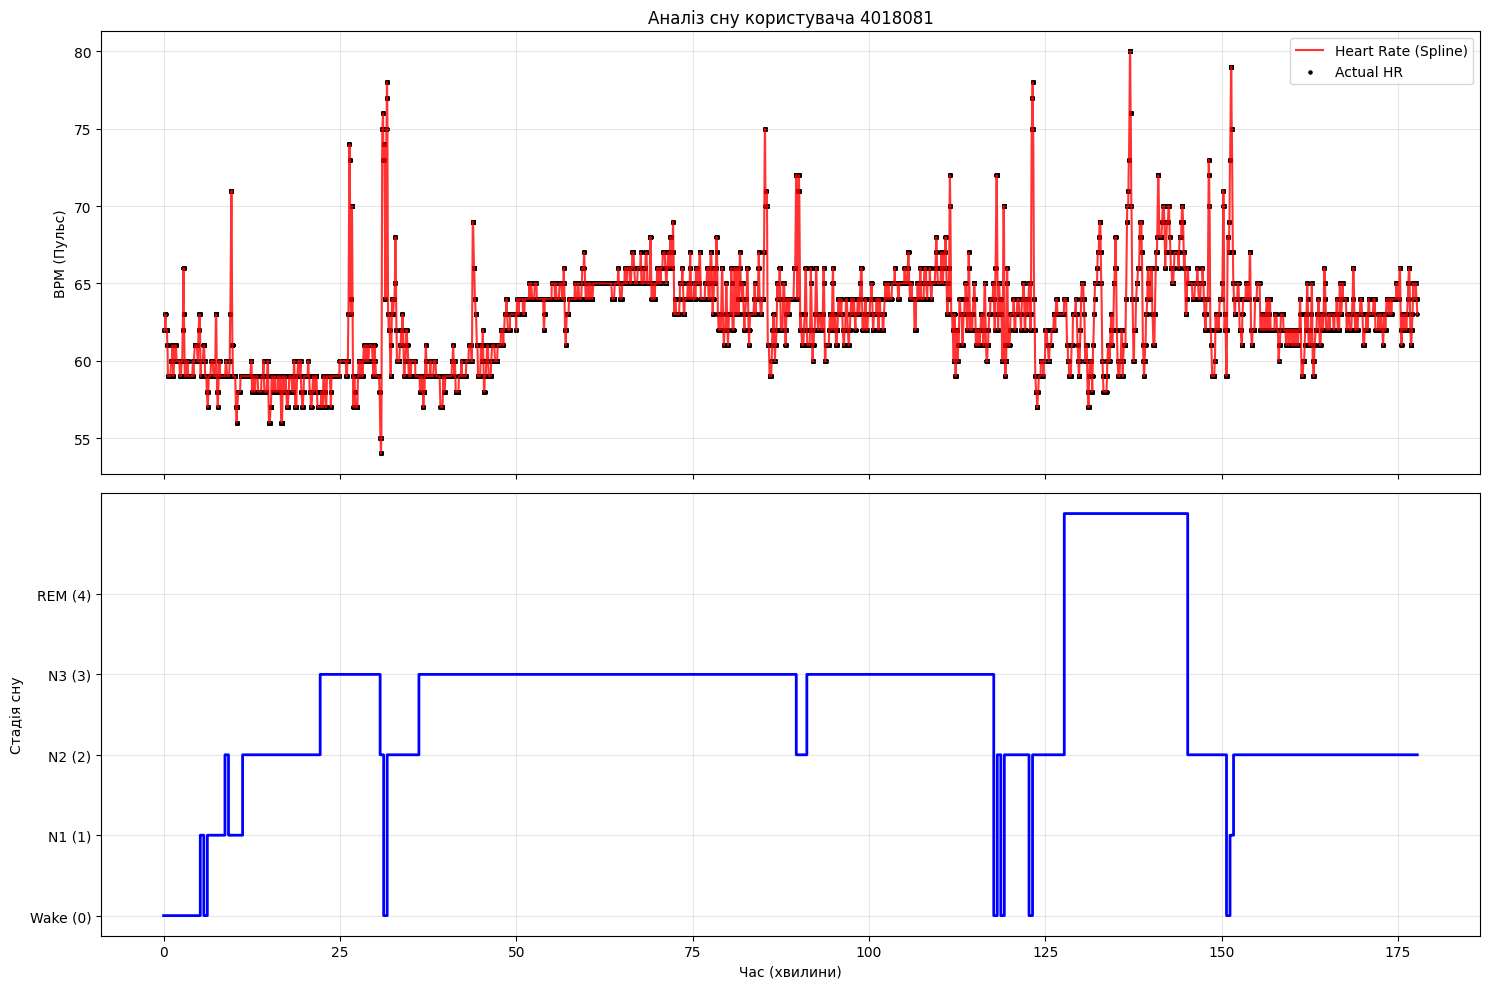

In [8]:
# Використовуємо ваш зріз даних
sample_size = 700000
start_idx = 141595
user_sample = df[df['user_id'] == target_user].iloc[start_idx : start_idx + sample_size].copy()

# Відносний час у хвилинах
user_sample['time_min'] = (user_sample['time'] - user_sample['time'].iloc[0]) / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- ГРАФІК ПУЛЬСУ ---
# Додаємо пульс із вашою сплайн-інтерполяцією
ax1.plot(user_sample['time_min'], user_sample['hr_spline'], color='red', label='Heart Rate (Spline)', alpha=0.8)
ax1.scatter(user_sample['time_min'], user_sample['heart_rate'], color='black', s=5, label='Actual HR')
ax1.set_ylabel('BPM (Пульс)')
ax1.set_title(f'Аналіз сну користувача {target_user}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- ГРАФІК ФАЗ СНУ (5 СТАДІЙ) ---
ax2.step(user_sample['time_min'], user_sample['sleep_stage'], where='post', color='blue', linewidth=2, label='Sleep Stage')

# Встановлюємо 5 рівнів (0, 1, 2, 3, 4)
# Примітка: у MMASH стадія 4 зазвичай відповідає REM
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(['Wake (0)', 'N1 (1)', 'N2 (2)', 'N3 (3)', 'REM (4)'])

ax2.set_ylabel('Стадія сну')
ax2.set_xlabel('Час (хвилини)')
ax2.grid(True, alpha=0.3)

# Порада: іноді зручно інвертувати вісь Y для сну, щоб "Wake" був зверху, а "Deep/REM" знизу
# ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
from scipy.signal import medfilt, butter, filtfilt

In [10]:
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.kalman import MerweScaledSigmaPoints

In [11]:


# 1. Параметри Баттерворта
fs = 50  # частота (Гц)
lowcut = 2.0
b, a = butter(4, lowcut/(0.5*fs), btype='low')

# 2. Параметри Ковзного середнього
window_size = 5

axes = ['x', 'y', 'z']
for ax in axes:
    # Баттерворт
    df[f'{ax}_butter'] = filtfilt(b, a, df[ax])
    # Ковзне середнє
    df[f'{ax}_moving_avg'] = df[ax].rolling(window=window_size, center=True).mean()

print("Прості фільтри застосовано.")

Прості фільтри застосовано.


In [12]:
def fx(x, dt):
    # Функція переходу (проста модель сталої швидкості або положення)
    return x

def hx(x):
    # Функція вимірювання (ми бачимо напряму X, Y, Z)
    return x

# Налаштування UKF
points = MerweScaledSigmaPoints(n=3, alpha=0.1, beta=2., kappa=0)
kf = UKF(dim_x=3, dim_z=3, fx=fx, hx=hx, dt=1.0/fs, points=points)

# Матриці шуму (треба підбирати!)
kf.P *= 0.1   # Початкова невпевненість
kf.R *= 0.05   # Шум сенсора (чим більше, тим сильніше згладжування)
kf.Q *= 0.01  # Шум процесу

ukf_data = []
# Проходимо по рядках (для швидкості візьмемо зріз, якщо датасет гігантський)
z_values = df[['x', 'y', 'z']].values

for z in z_values:
    kf.predict()
    kf.update(z)
    ukf_data.append(kf.x.copy())

ukf_res = np.array(ukf_data)
df['x_ukf'], df['y_ukf'], df['z_ukf'] = ukf_res[:, 0], ukf_res[:, 1], ukf_res[:, 2]

print("UKF фільтрація завершена.")

UKF фільтрація завершена.


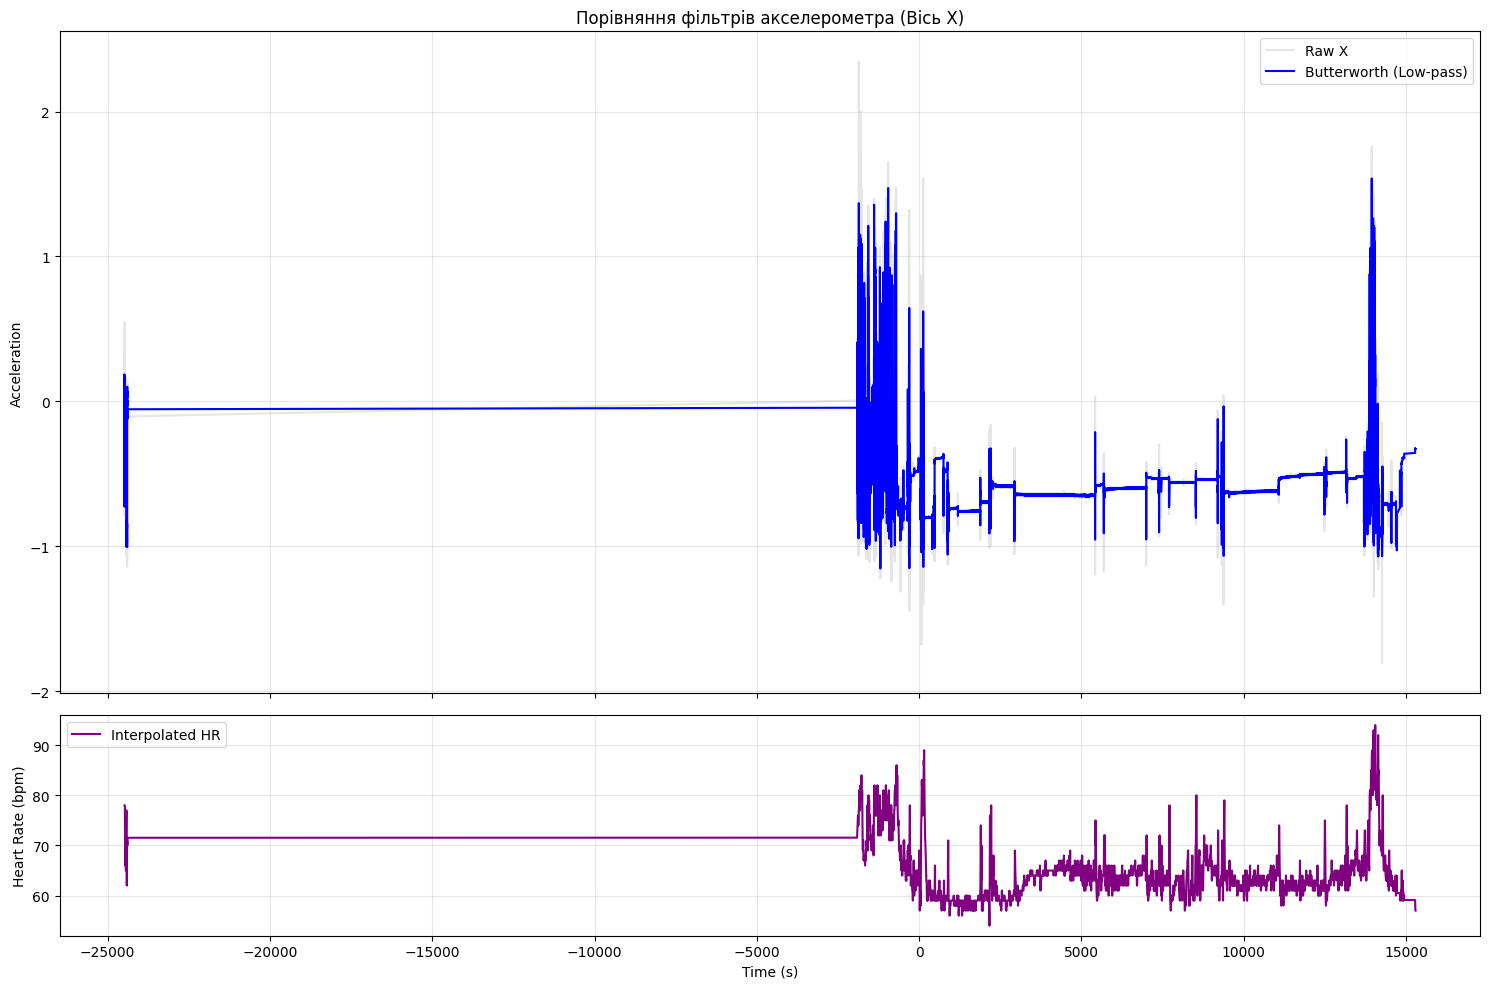

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Графік акселерометра (Вісь X)
ax1.plot(df['time'], df['x'], alpha=0.2, label='Raw X', color='gray')
ax1.plot(df['time'], df['x_butter'], label='Butterworth (Low-pass)', color='blue', linewidth=1.5)
#ax1.plot(df['time'], df['x_moving_avg'], label='Moving Average', color='green', linestyle='--')
#ax1.plot(df['time'], df['x_ukf'], label='UKF (Sigma Points)', color='red', linewidth=2)

ax1.set_title('Порівняння фільтрів акселерометра (Вісь X)')
ax1.set_ylabel('Acceleration')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Графік пульсу
ax2.plot(df['time'], df['hr_linear'], color='purple', label='Interpolated HR')
ax2.set_ylabel('Heart Rate (bpm)')
ax2.set_xlabel('Time (s)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

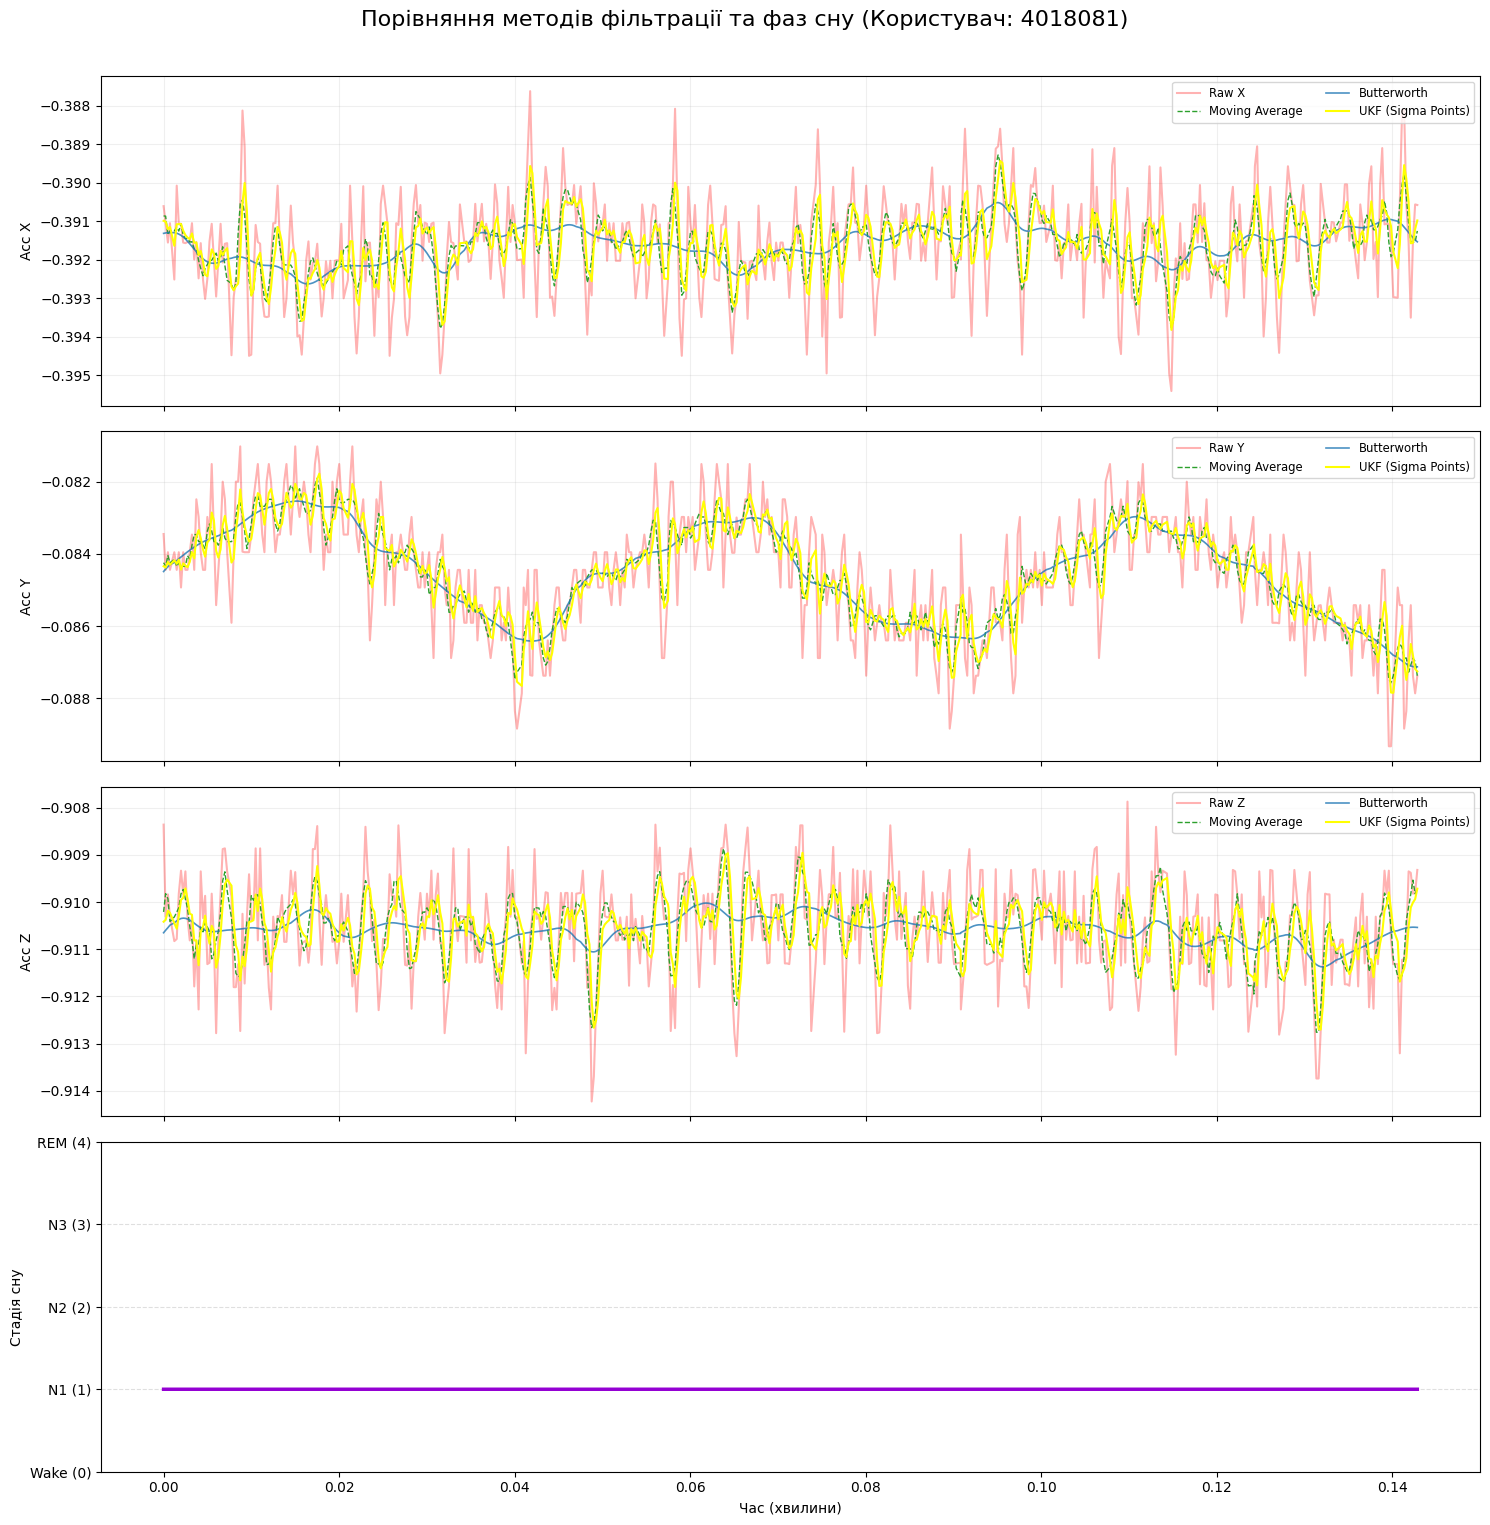

In [14]:
# Використовуємо ваш зріз даних
sample_size = 550
start_idx = 161595
user_sample = df[df['user_id'] == target_user].iloc[start_idx : start_idx + sample_size].copy()

user_sample['time_min'] = (user_sample['time'] - user_sample['time'].iloc[0]) / 60

# Створюємо 4 підграфіки (X, Y, Z та Фази сну)
fig, axs = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes_labels = ['x', 'y', 'z']
# Кольори для різних методів фільтрації
filter_colors = {
    'butter': '#1f77b4',  # Синій
    'avg': '#2ca02c',     # Зелений
    'ukf': 'yellow'      # Червоний
}

# --- ГРАФІКИ АКСЕЛЕРОМЕТРА ---
for i, ax_name in enumerate(axes_labels):
    # 1. Сирі дані (Raw)
    axs[i].plot(user_sample['time_min'], user_sample[ax_name],
                color='red', alpha=0.3, label=f'Raw {ax_name.upper()}')

    # 2. Moving Average (Ковзне середнє)
    col_avg = f'{ax_name}_moving_avg'
    if col_avg in user_sample.columns:
        axs[i].plot(user_sample['time_min'], user_sample[col_avg],
                    color=filter_colors['avg'], label='Moving Average', linewidth=1, linestyle='--')

    # 3. Butterworth Filter
    col_butter = f'{ax_name}_butter'
    if col_butter in user_sample.columns:
        axs[i].plot(user_sample['time_min'], user_sample[col_butter],
                    color=filter_colors['butter'], label='Butterworth', linewidth=1.2, alpha=0.8)

    # 4. Unscented Kalman Filter (UKF)
    col_ukf = f'{ax_name}_ukf'
    if col_ukf in user_sample.columns:
        axs[i].plot(user_sample['time_min'], user_sample[col_ukf],
                    color=filter_colors['ukf'], label='UKF (Sigma Points)', linewidth=1.5)

    axs[i].set_ylabel(f'Acc {ax_name.upper()}')
    axs[i].legend(loc='upper right', fontsize='small', ncol=2)
    axs[i].grid(True, alpha=0.2)

# --- ГРАФІК ФАЗ СНУ (5 СТАДІЙ) ---
axs[3].step(user_sample['time_min'], user_sample['sleep_stage'],
            where='post', color='darkviolet', linewidth=2.5, label='Sleep Stage')

# Налаштування осі Y для 5 стадій
axs[3].set_yticks([0, 1, 2, 3, 4])
axs[3].set_yticklabels(['Wake (0)', 'N1 (1)', 'N2 (2)', 'N3 (3)', 'REM (4)'])

axs[3].set_ylabel('Стадія сну')
axs[3].set_xlabel('Час (хвилини)')
axs[3].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle(f'Порівняння методів фільтрації та фаз сну (Користувач: {target_user})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()